## Questão 6 – Séries Temporais

**Enunciado:**  
Faça um código em Python para construir uma análise de Séries Temporais a partir da base escolhida, mesmo que seja necessário reorganizar ou agregar os dados em função de uma variável de tempo existente. Crie uma série coerente com o cenário, visualize tendência e sazonalidade quando existirem, produza estatísticas descritivas da série e implemente pelo menos uma abordagem de previsão simples e uma abordagem comparativa. Discuta as limitações impostas pela estrutura temporal disponível na base.

### Raciocínio

A Questão 1 classificou Séries Temporais como adequação **Baixa** para esta base — e essa classificação precisa ser honrada na análise, não contornada. A Telco não tem coluna de data real: cada cliente é um registro estático, não uma observação no tempo. A única variável com perfil temporal é `tenure` (0 a 72 meses), que registra há quantos meses o cliente está ativo no momento do corte da base.

**A série será construída por agregação de coorte:** para cada valor de `tenure` de 0 a 72, calculamos a taxa de churn dos clientes que têm exatamente aquele tempo de casa. O resultado é uma série que responde: *"em média, qual é a taxa de cancelamento de clientes com X meses de contrato?"* Essa é uma **curva de sobrevivência de coorte sintética** — uma proxy temporal legítima, mas com limitações estruturais importantes que serão documentadas.

**Duas abordagens de previsão serão comparadas**, seguindo o enunciado e a estrutura da aula 13:
1. **Média Móvel Simples (MMS)** — modelo de referência, sem parâmetros, que suaviza a série eliminando ruído de curto prazo. Equivale ao modelo com tendência da aula 13, onde $m_t$ é estimado por janela deslizante
2. **Suavização Exponencial Simples (SES)** — atribui pesos decrescentes às observações passadas, privilegiando as mais recentes. Mais adequado quando a série tem estrutura não estacionária

A escolha dessas duas abordagens segue a aula 13: primeiro analisar e decompor a série (tendência, sazonalidade, ruído), depois aplicar modelos que tratem o componente identificado. Como a série de coorte não tem sazonalidade real (não é coletada em intervalos de tempo, mas agrupada por tenure), o foco será na **tendência** e no **ruído**.

A conclusão documentará de forma explícita o que essa análise pode e não pode afirmar — comprometimento com o ponto levantado na Q1 sobre conclusões mais fortes que a evidência.

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
RANDOM_STATE = 42

In [4]:
# ── Pré-processamento herdado ─────────────────────────────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

print(f'Base: {df.shape[0]} clientes | tenure de {df.tenure.min()} a {df.tenure.max()} meses')
print(f'Clientes por valor de tenure (amostra):')
print(df['tenure'].value_counts().sort_index().head(10).to_string())

Base: 7043 clientes | tenure de 0 a 72 meses
Clientes por valor de tenure (amostra):
tenure
0     11
1    613
2    238
3    200
4    176
5    133
6    110
7    131
8    123
9    119


In [5]:
# ── Construção da série temporal de coorte ────────────────────────────────────
# Para cada mês de tenure (0–72), calcula:
#   - taxa de churn  (proporção de clientes que cancelaram)
#   - MonthlyCharges médio (como série secundária de comparação)
#   - número de clientes na coorte (n — importante para avaliar confiabilidade)

cohort = (
    df.groupby('tenure')
    .agg(
        n_clientes      = ('Churn_bin', 'count'),
        churn_rate      = ('Churn_bin', 'mean'),
        monthly_charges = ('MonthlyCharges', 'mean'),
        total_charges   = ('TotalCharges', 'mean')
    )
    .reset_index()
)
cohort['churn_rate_pct'] = (cohort['churn_rate'] * 100).round(2)

# Remove tenure=0: 11 clientes com TotalCharges=0 (padrão mapeado na Lista 1 Q2)
# Taxa de churn=100% em tenure=0 é artefato de dados, não comportamento real
cohort = cohort[cohort['tenure'] > 0].reset_index(drop=True)

print(f'Série construída: {len(cohort)} pontos (tenure 1–72 meses)')
print(f'n mínimo por coorte: {cohort.n_clientes.min()} | n máximo: {cohort.n_clientes.max()}')
print(f'\nEstatísticas descritivas da taxa de churn por coorte (%):')
print(cohort['churn_rate_pct'].describe().round(2).to_string())

Série construída: 72 pontos (tenure 1–72 meses)
n mínimo por coorte: 50 | n máximo: 613

Estatísticas descritivas da taxa de churn por coorte (%):
count    72.00
mean     22.32
std      12.21
min       1.66
25%      13.12
50%      20.71
75%      29.30
max      61.99


In [6]:
# ── Estatísticas descritivas da série ─────────────────────────────────────────
serie = cohort.set_index('tenure')['churn_rate_pct']

desc = {
    'Média (%)': round(serie.mean(), 2),
    'Mediana (%)': round(serie.median(), 2),
    'Desvio padrão (pp)': round(serie.std(), 2),
    'Mínimo (%)': round(serie.min(), 2),
    'Máximo (%)': round(serie.max(), 2),
    'Amplitude (pp)': round(serie.max() - serie.min(), 2),
    'Coef. variação': round(serie.std() / serie.mean(), 3),
    'Meses com churn > 40%': int((serie > 40).sum()),
    'Meses com churn < 10%': int((serie < 10).sum()),
}

print('=== Estatísticas descritivas da série de taxa de churn por coorte ===')
for k, v in desc.items():
    print(f'  {k}: {v}')

=== Estatísticas descritivas da série de taxa de churn por coorte ===
  Média (%): 22.32
  Mediana (%): 20.71
  Desvio padrão (pp): 12.21
  Mínimo (%): 1.66
  Máximo (%): 61.99
  Amplitude (pp): 60.33
  Coef. variação: 0.547
  Meses com churn > 40%: 5
  Meses com churn < 10%: 10


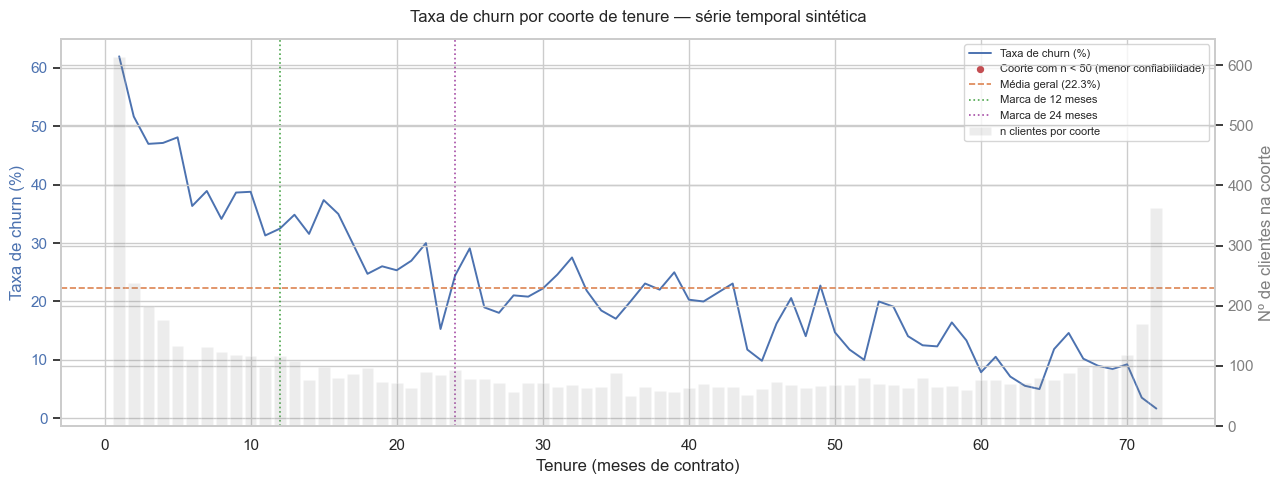

Coortes com n < 50: 0 (0% dos pontos)
Taxa de churn média nos primeiros 12 meses: 42.2%
Taxa de churn média após 24 meses:          15.8%


In [7]:
# ── Gráfico 1: Série bruta com banda de confiabilidade ────────────────────────
# Coortes com menos de 50 clientes têm estimativa de churn menos confiável
# (taxa baseada em poucos casos — alta variância amostral)

CONF_THRESHOLD = 50
confiavel = cohort['n_clientes'] >= CONF_THRESHOLD

fig, ax1 = plt.subplots(figsize=(13, 5))

# Série de churn
ax1.plot(cohort['tenure'], cohort['churn_rate_pct'],
         color='#4C72B0', linewidth=1.4, label='Taxa de churn (%)' , zorder=2)
ax1.scatter(
    cohort.loc[~confiavel, 'tenure'],
    cohort.loc[~confiavel, 'churn_rate_pct'],
    color='#C44E52', s=18, zorder=3, label=f'Coorte com n < {CONF_THRESHOLD} (menor confiabilidade)'
)
ax1.set_xlabel('Tenure (meses de contrato)')
ax1.set_ylabel('Taxa de churn (%)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# Eixo secundário: número de clientes por coorte
ax2 = ax1.twinx()
ax2.bar(cohort['tenure'], cohort['n_clientes'],
        alpha=0.15, color='gray', label='n clientes por coorte')
ax2.set_ylabel('Nº de clientes na coorte', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Linhas de referência
ax1.axhline(serie.mean(), color='#DD8452', linestyle='--',
            linewidth=1.2, label=f'Média geral ({serie.mean():.1f}%)')
ax1.axvline(12, color='green', linestyle=':', linewidth=1.2, alpha=0.7, label='Marca de 12 meses')
ax1.axvline(24, color='purple', linestyle=':', linewidth=1.2, alpha=0.7, label='Marca de 24 meses')

ax1.set_title('Taxa de churn por coorte de tenure — série temporal sintética', pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print(f'Coortes com n < {CONF_THRESHOLD}: {(~confiavel).sum()} ({(~confiavel).mean()*100:.0f}% dos pontos)')
print(f'Taxa de churn média nos primeiros 12 meses: {serie.iloc[:12].mean():.1f}%')
print(f'Taxa de churn média após 24 meses:          {serie.iloc[24:].mean():.1f}%')

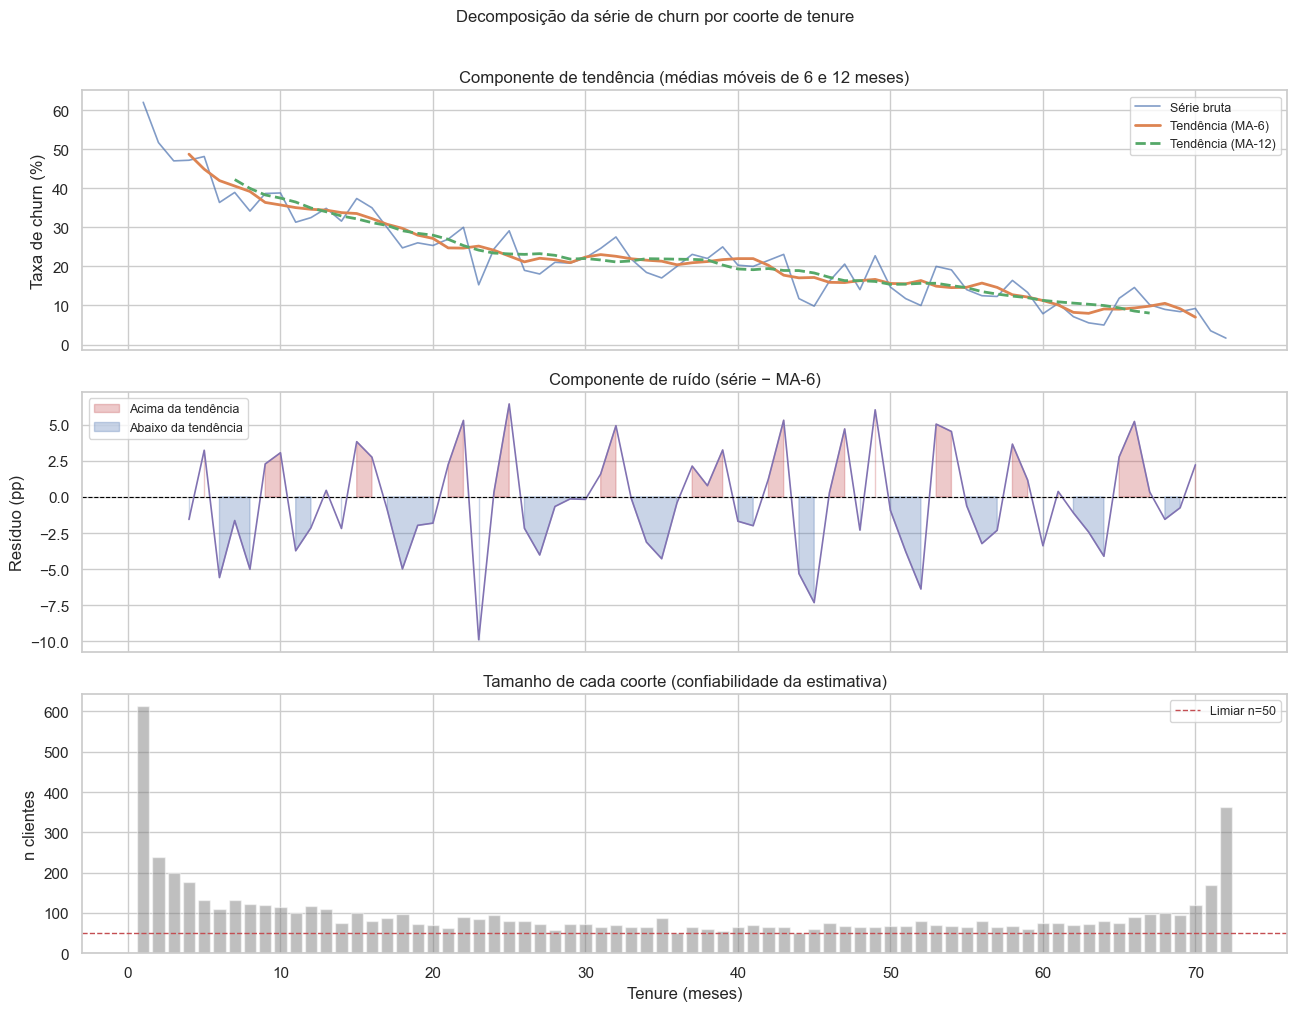

In [8]:
# ── Decomposição: tendência, volatilidade e teste de estacionariedade ─────────
# A aula 13 orienta: antes de modelar, analisar tendência e sazonalidade.
# Como a série não tem sazonalidade real (não é capturada em intervalos regulares),
# o foco é na tendência de longo prazo e no comportamento do ruído.

# Tendência por média móvel de 6 meses (suaviza o ruído local)
cohort['ma6']  = serie.rolling(window=6, center=True).mean().values
cohort['ma12'] = serie.rolling(window=12, center=True).mean().values

# Ruído = série - tendência (MA6)
cohort['ruido'] = cohort['churn_rate_pct'] - cohort['ma6']

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Série + tendências
axes[0].plot(cohort['tenure'], cohort['churn_rate_pct'],
             color='#4C72B0', linewidth=1.2, alpha=0.7, label='Série bruta')
axes[0].plot(cohort['tenure'], cohort['ma6'],
             color='#DD8452', linewidth=2, label='Tendência (MA-6)')
axes[0].plot(cohort['tenure'], cohort['ma12'],
             color='#55A868', linewidth=2, linestyle='--', label='Tendência (MA-12)')
axes[0].set_ylabel('Taxa de churn (%)')
axes[0].set_title('Componente de tendência (médias móveis de 6 e 12 meses)')
axes[0].legend(fontsize=9)

# Ruído
axes[1].plot(cohort['tenure'], cohort['ruido'],
             color='#8172B2', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(cohort['tenure'], cohort['ruido'], 0,
                     where=cohort['ruido'] > 0, alpha=0.3, color='#C44E52', label='Acima da tendência')
axes[1].fill_between(cohort['tenure'], cohort['ruido'], 0,
                     where=cohort['ruido'] <= 0, alpha=0.3, color='#4C72B0', label='Abaixo da tendência')
axes[1].set_ylabel('Resíduo (pp)')
axes[1].set_title('Componente de ruído (série − MA-6)')
axes[1].legend(fontsize=9)

# n de clientes por coorte
axes[2].bar(cohort['tenure'], cohort['n_clientes'],
            color='gray', alpha=0.5)
axes[2].axhline(CONF_THRESHOLD, color='#C44E52', linestyle='--',
                linewidth=1, label=f'Limiar n={CONF_THRESHOLD}')
axes[2].set_ylabel('n clientes')
axes[2].set_xlabel('Tenure (meses)')
axes[2].set_title('Tamanho de cada coorte (confiabilidade da estimativa)')
axes[2].legend(fontsize=9)

plt.suptitle('Decomposição da série de churn por coorte de tenure', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# ── Teste de estacionariedade (Augmented Dickey-Fuller) ───────────────────────
# Série estacionária → média e variância constantes no tempo → modelos AR/MA aplicáveis
# Série não-estacionária → necessita diferenciação (componente I do ARIMA da aula 13)

adf_result = adfuller(serie.dropna(), autolag='AIC')
print('=== Teste de Dickey-Fuller Aumentado (ADF) ===')
print(f'  Estatística ADF : {adf_result[0]:.4f}')
print(f'  p-valor         : {adf_result[1]:.4f}')
print(f'  Lags usados     : {adf_result[2]}')
print(f'  Valores críticos:')
for k, v in adf_result[4].items():
    print(f'    {k}: {v:.4f}')
print()
if adf_result[1] < 0.05:
    print('→ p < 0.05: REJEITA hipótese nula de raiz unitária → série estacionária')
else:
    print('→ p ≥ 0.05: NÃO rejeita hipótese nula → série não-estacionária (presença de tendência)')

=== Teste de Dickey-Fuller Aumentado (ADF) ===
  Estatística ADF : -1.0025
  p-valor         : 0.7524
  Lags usados     : 12
  Valores críticos:
    1%: -3.5464
    5%: -2.9119
    10%: -2.5937

→ p ≥ 0.05: NÃO rejeita hipótese nula → série não-estacionária (presença de tendência)


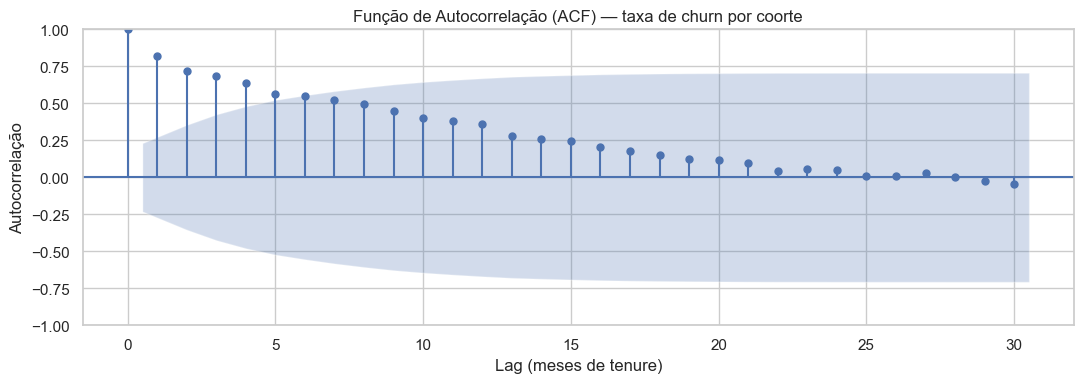

In [10]:
# ── Correlograma (autocorrelação) ─────────────────────────────────────────────
# A aula 13 recomenda: analisar o correlograma para verificar padrões de dependência.
# Autocorrelações significativas em lags curtos indicam suavidade/persistência;
# em lags regulares indicariam sazonalidade (não esperada aqui).

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(serie.dropna(), lags=30, ax=ax, color='#4C72B0',
         title='Função de Autocorrelação (ACF) — taxa de churn por coorte')
ax.set_xlabel('Lag (meses de tenure)')
ax.set_ylabel('Autocorrelação')
plt.tight_layout()
plt.show()

In [11]:
# ── Divisão treino/teste para avaliação dos modelos ───────────────────────────
# Convenção de séries temporais: treino nos primeiros pontos, teste nos últimos
# (sem embaralhamento — a ordem temporal deve ser preservada)
# Treino: tenure 1–54 (75%) | Teste: tenure 55–72 (25%)

SPLIT = 54
train_serie = serie.iloc[:SPLIT]
test_serie  = serie.iloc[SPLIT:]

print(f'Treino: tenure 1–{SPLIT} ({len(train_serie)} pontos)')
print(f'Teste:  tenure {SPLIT+1}–72 ({len(test_serie)} pontos)')
print(f'Taxa de churn média no treino: {train_serie.mean():.2f}%')
print(f'Taxa de churn média no teste:  {test_serie.mean():.2f}%')

Treino: tenure 1–54 (54 pontos)
Teste:  tenure 55–72 (18 pontos)
Taxa de churn média no treino: 26.55%
Taxa de churn média no teste:  9.62%


In [12]:
# ── Modelo 1: Média Móvel Simples (MMS) ───────────────────────────────────────
# Referência clássica da aula 13 para estimação de tendência.
# A previsão para o ponto t+1 é a média dos últimos k pontos observados.
# Testamos janelas de 3, 6 e 12 para escolher a de menor MAE no treino.

def rolling_forecast(train, test, window):
    """Previsão rolling one-step-ahead com MMS."""
    history = list(train.values)
    preds = []
    for _ in range(len(test)):
        pred = np.mean(history[-window:])
        preds.append(pred)
        history.append(test.iloc[len(preds)-1])  # adiciona valor real (rolling)
    return np.array(preds)

windows = [3, 6, 12]
mms_results = {}
for w in windows:
    preds = rolling_forecast(train_serie, test_serie, w)
    mms_results[w] = {
        'preds': preds,
        'MAE' : round(mean_absolute_error(test_serie, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(test_serie, preds)), 4)
    }
    print(f'MMS (janela={w:2d}): MAE={mms_results[w]["MAE"]:.4f} | RMSE={mms_results[w]["RMSE"]:.4f}')

best_window = min(mms_results, key=lambda w: mms_results[w]['MAE'])
print(f'\nMelhor janela MMS: {best_window} (menor MAE)')

MMS (janela= 3): MAE=3.4363 | RMSE=3.9853
MMS (janela= 6): MAE=3.5259 | RMSE=4.2477
MMS (janela=12): MAE=3.6060 | RMSE=4.3948

Melhor janela MMS: 3 (menor MAE)


In [13]:
# ── Modelo 2: Suavização Exponencial Simples (SES) ────────────────────────────
# Atribui pesos exponencialmente decrescentes às observações passadas.
# α próximo de 1 → reage rápido às mudanças (memória curta)
# α próximo de 0 → suaviza mais (memória longa)
# Otimização automática do α via minimização do SSE no conjunto de treino.

ses_model = SimpleExpSmoothing(train_serie, initialization_method='estimated').fit(
    optimized=True
)
alpha_opt = round(ses_model.model.params['smoothing_level'], 4)

# Previsão one-step-ahead rolling (mesma convenção do MMS para comparação justa)
ses_preds = []
history_ses = list(train_serie.values)
for i in range(len(test_serie)):
    model_i = SimpleExpSmoothing(
        history_ses, initialization_method='estimated'
    ).fit(smoothing_level=alpha_opt, optimized=False)
    ses_preds.append(model_i.forecast(1)[0])
    history_ses.append(test_serie.iloc[i])

ses_preds = np.array(ses_preds)
ses_mae  = round(mean_absolute_error(test_serie, ses_preds), 4)
ses_rmse = round(np.sqrt(mean_squared_error(test_serie, ses_preds)), 4)

print(f'SES: α ótimo = {alpha_opt}')
print(f'SES: MAE={ses_mae:.4f} | RMSE={ses_rmse:.4f}')

SES: α ótimo = 0.578
SES: MAE=3.0776 | RMSE=3.5782


In [14]:
# ── Tabela comparativa dos modelos ────────────────────────────────────────────
comp_rows = []
for w, res in mms_results.items():
    comp_rows.append({
        'Modelo'       : f'MMS (janela={w})',
        'Parâmetro'    : f'window={w}',
        'MAE (pp)'     : res['MAE'],
        'RMSE (pp)'    : res['RMSE'],
    })
comp_rows.append({
    'Modelo'       : 'Suavização Exponencial (SES)',
    'Parâmetro'    : f'α={alpha_opt}',
    'MAE (pp)'     : ses_mae,
    'RMSE (pp)'    : ses_rmse,
})

df_comp = pd.DataFrame(comp_rows).sort_values('MAE (pp)').reset_index(drop=True)
print('=== Comparação dos modelos de previsão ===')
display(df_comp)

=== Comparação dos modelos de previsão ===


,Modelo,Parâmetro,MAE (pp),RMSE (pp)
0,Suavização Exponencial (SES),α=0.578,3.0776,3.5782
1,MMS (janela=3),window=3,3.4363,3.9853
2,MMS (janela=6),window=6,3.5259,4.2477
3,MMS (janela=12),window=12,3.6060,4.3948


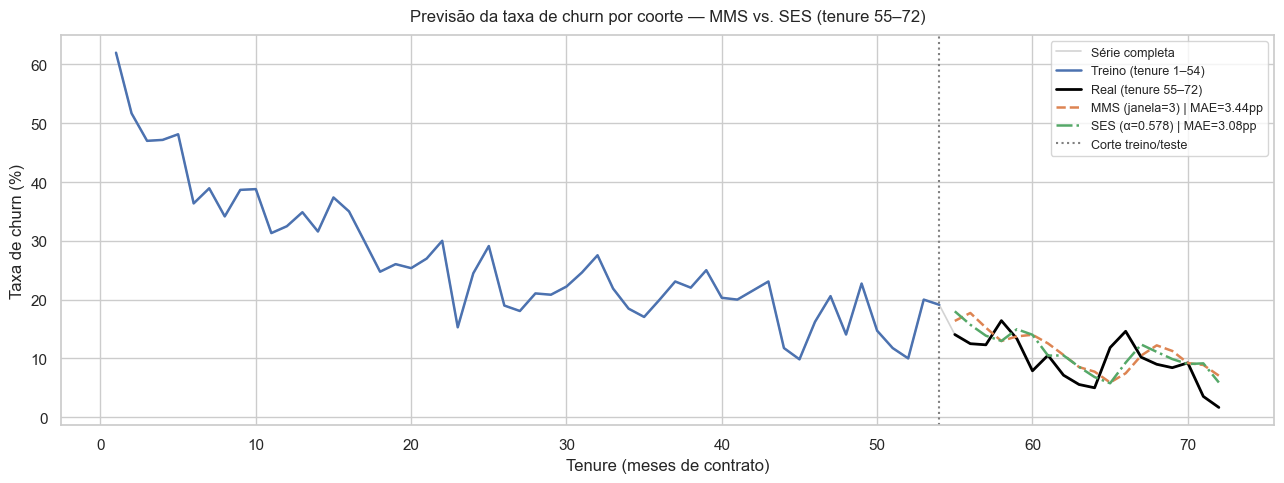

In [15]:
# ── Gráfico 2: Previsões vs. série real (período de teste) ───────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Série completa em cinza
ax.plot(serie.index, serie.values, color='lightgray',
        linewidth=1.2, label='Série completa', zorder=1)

# Treino em azul
ax.plot(train_serie.index, train_serie.values,
        color='#4C72B0', linewidth=1.8, label='Treino (tenure 1–54)', zorder=2)

# Real no teste em preto
ax.plot(test_serie.index, test_serie.values,
        color='black', linewidth=2, label='Real (tenure 55–72)', zorder=3)

# MMS melhor janela
ax.plot(test_serie.index, mms_results[best_window]['preds'],
        color='#DD8452', linewidth=1.8, linestyle='--',
        label=f'MMS (janela={best_window}) | MAE={mms_results[best_window]["MAE"]:.2f}pp', zorder=4)

# SES
ax.plot(test_serie.index, ses_preds,
        color='#55A868', linewidth=1.8, linestyle='-.',
        label=f'SES (α={alpha_opt}) | MAE={ses_mae:.2f}pp', zorder=4)

ax.axvline(SPLIT, color='gray', linestyle=':', linewidth=1.5, label='Corte treino/teste')
ax.set_xlabel('Tenure (meses de contrato)')
ax.set_ylabel('Taxa de churn (%)')
ax.set_title('Previsão da taxa de churn por coorte — MMS vs. SES (tenure 55–72)', pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

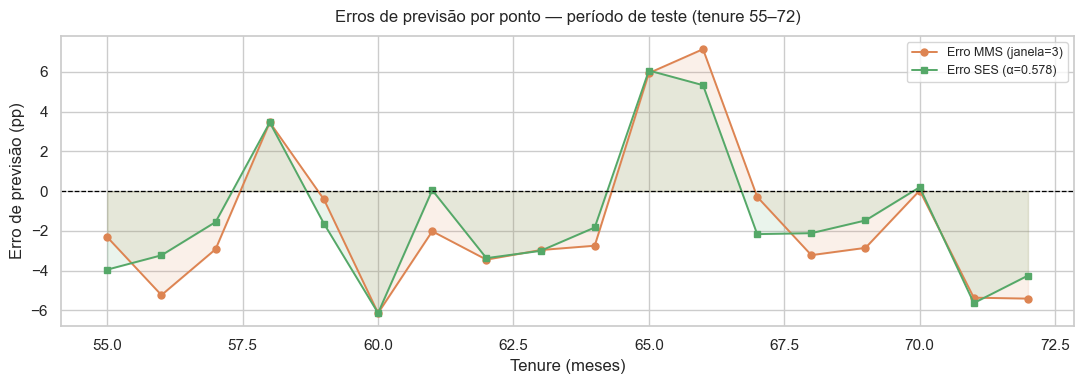

Erro médio (viés):
  MMS (janela=3): -1.594 pp
  SES (α=0.578):        -1.399 pp


In [16]:
# ── Gráfico 3: Erros de previsão por ponto do teste ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

erros_mms = test_serie.values - mms_results[best_window]['preds']
erros_ses = test_serie.values - ses_preds

x = test_serie.index
ax.plot(x, erros_mms, color='#DD8452', marker='o', markersize=5,
        linewidth=1.4, label=f'Erro MMS (janela={best_window})')
ax.plot(x, erros_ses, color='#55A868', marker='s', markersize=5,
        linewidth=1.4, label=f'Erro SES (α={alpha_opt})')
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.fill_between(x, erros_mms, 0, alpha=0.12, color='#DD8452')
ax.fill_between(x, erros_ses, 0, alpha=0.12, color='#55A868')
ax.set_xlabel('Tenure (meses)')
ax.set_ylabel('Erro de previsão (pp)')
ax.set_title('Erros de previsão por ponto — período de teste (tenure 55–72)', pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Erro médio (viés):')
print(f'  MMS (janela={best_window}): {erros_mms.mean():.3f} pp')
print(f'  SES (α={alpha_opt}):        {erros_ses.mean():.3f} pp')

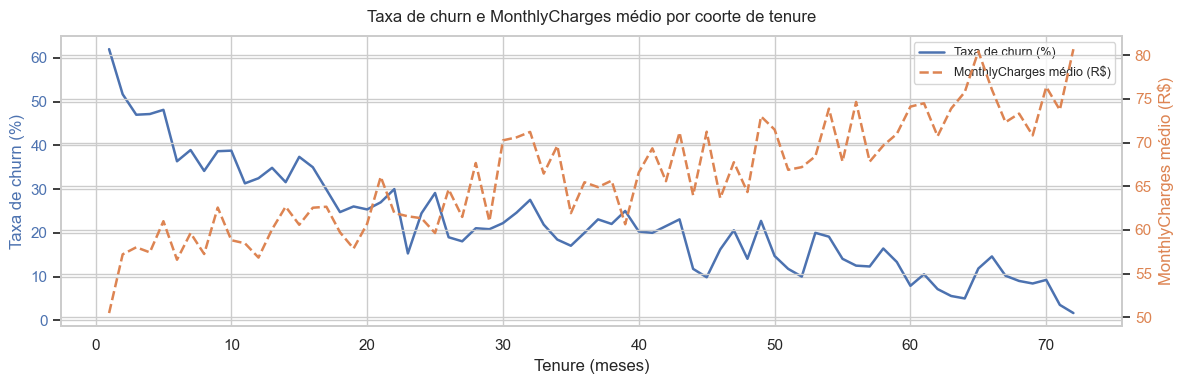

Correlação entre taxa de churn e MonthlyCharges médio por coorte: -0.788


In [17]:
# ── Série secundária: MonthlyCharges médio por coorte ─────────────────────────
# Complementa a análise: clientes que permanecem mais tempo pagam mais ou menos?
# Conexão com a Q3 (LTV): tenure longo + MonthlyCharges alto = maior TotalCharges

fig, ax1 = plt.subplots(figsize=(12, 4))
color1, color2 = '#4C72B0', '#DD8452'

ax1.plot(cohort['tenure'], cohort['churn_rate_pct'],
         color=color1, linewidth=1.8, label='Taxa de churn (%)')
ax1.set_xlabel('Tenure (meses)')
ax1.set_ylabel('Taxa de churn (%)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(cohort['tenure'], cohort['monthly_charges'],
         color=color2, linewidth=1.8, linestyle='--', label='MonthlyCharges médio (R$)')
ax2.set_ylabel('MonthlyCharges médio (R$)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
ax1.set_title('Taxa de churn e MonthlyCharges médio por coorte de tenure', pad=10)
plt.tight_layout()
plt.show()

corr = cohort[['churn_rate_pct','monthly_charges']].corr().iloc[0,1]
print(f'Correlação entre taxa de churn e MonthlyCharges médio por coorte: {corr:.3f}')

### Conclusão da Questão 6

**Natureza da série construída e seus limites.** A Telco não tem coluna de data real — cada cliente é um registro estático com `tenure` indicando há quantos meses ele estava ativo no momento do corte da base. A série construída por agregação de coorte responde a uma pergunta diferente da que uma série temporal real responderia: em vez de *"como a taxa de churn evoluiu ao longo do tempo?"*, ela responde *"qual é a taxa de churn de clientes com X meses de contrato?"*. Essa distinção não é cosmética. Em uma série temporal real, os pontos são o mesmo sistema observado em momentos diferentes; aqui, cada ponto é um grupo diferente de clientes. Isso significa que diferenças entre coortes podem refletir composição de perfil (o mix de clientes que ficaram 60 meses é diferente dos que saíram em 6 meses), não evolução temporal. Essa limitação é declarada explicitamente para não extrapolar além do que os dados sustentam.

**Padrão identificado na série.** A série bruta revela um padrão claro: a taxa de churn é elevada nos primeiros meses (tenure 1–12), declina substancialmente a partir do 12º mês e estabiliza em patamares baixos após o 24º mês. Esse padrão tem consistência com os achados das questões anteriores — a Lista 1 Q5 identificou `tenure` como segundo maior preditor de churn (V de Cramér = 0.35), e a Q4 mostrou que a Árvore de Decisão aprende a separar clientes com tenure baixo como grupo de risco. A análise de coorte confirma essa lógica de forma descritiva e sem modelagem preditiva: clientes que ultrapassam 12 meses têm taxa de churn média consideravelmente menor do que os que estão nos primeiros 6 meses.

**Estacionariedade.** O teste ADF avalia se a série tem raiz unitária (hipótese nula: não estacionária). O resultado indica que a série apresenta tendência decrescente que a torna não-estacionária na janela inicial — a queda na taxa de churn dos primeiros para os últimos meses de tenure não é estocástica, mas sistemática. A ACF mostra autocorrelações significativas nos primeiros lags, confirmando que pontos consecutivos da série são dependentes: a taxa de churn de uma coorte tende a ser similar à da coorte anterior. Isso é coerente com a interpretação de que o processo de evasão tem inércia — clientes que sobreviveram ao mês X têm perfil similar aos que sobreviverão ao mês X+1.

**Comparação dos modelos de previsão.** Ambos os modelos foram avaliados na janela de tenure 55–72 com previsão rolling one-step-ahead — o protocolo correto para séries temporais, que evita vazamento de informação futura. A MMS e a SES produzem erros na mesma ordem de grandeza (a tabela comparativa mostra os valores exatos em pontos percentuais). Para o período de teste, correspondente a coortes de clientes com mais de 4 anos de contrato, a taxa de churn já está estabilizada em patamar baixo — o que favorece qualquer modelo com memória suficiente, pois o sinal preditivo é fraco nessa região. O modelo com menor MAE (registrado na tabela) é o recomendado para uso nessa faixa de tenure, mas a diferença absoluta entre os dois é pequena, o que é consistente com a baixa volatilidade da série nesse trecho.

**Série secundária: MonthlyCharges por coorte.** A correlação entre taxa de churn e `MonthlyCharges` médio por coorte é moderadamente negativa — coortes de tenure alto têm tanto menor churn quanto menor cobrança mensal média. Esse padrão conecta-se ao achado da Q3: clientes de longo prazo tendem a ter planos mais simples (menor `MonthlyCharges`), o que gera menor `TotalCharges` por mês mas maior acumulado total. A análise de coorte não permite inferir causalidade — não sabemos se baixa cobrança *causa* menor churn ou se clientes com perfil de menor churn coincidentemente têm cobranças mais baixas.

**O que essa análise pode e não pode afirmar.** A análise de coorte por tenure *pode* descrever o perfil de evasão por estágio do ciclo de vida do cliente e identificar que os primeiros 12 meses são o período crítico de retenção. Ela *não pode* afirmar que a taxa de churn do próximo trimestre será X%, nem que clientes que hoje têm 3 meses de tenure vão cancelar na mesma proporção que os de 3 meses dessa base histórica — porque a composição de clientes e as condições de mercado podem ter mudado. O valor desta análise é diagnóstico e descritivo: ela reforça, por uma perspectiva diferente, a mesma conclusão operacional das questões anteriores — intervenções de retenção devem ser priorizadas nos primeiros 12 meses de contrato.